In [160]:
import pandas as pd
import numpy
from load_data import get_2022_data
import seaborn as sns
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import hdbscan

In [2]:
df, meta = get_2022_data()
df.head()

Data Collected...
Data Shape: (16748, 116)


,wt_final,wt_time,xStrata,Reg9,LondInOut,LA_2023,Age9,nadult,nchild,Disab3,...,MONTHS_12_BASESOFTBALL_F13,MONTHS_12_LACROSSE_F14,MONTHS_12_GOALBALL_F15,MONTHS_12_HANDBALL_F16,MEMS7_IN_SPORTCOUNT_A01,MEMS7_OUT_SPORTCOUNT_A01,WHOWITHA_SPORTCOUNT_A01,WHOWITHB_SPORTCOUNT_A01,WHOWITHC_SPORTCOUNT_A01,WHOWITHD_SPORTCOUNT_A01
10,0.589497,0.476685,117.0,3.0,1.0,114.0,5.0,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0
33,0.962646,1.165975,129.0,3.0,2.0,126.0,NaN,1.0,0.0,3.0,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0
52,3.840907,3.882306,9.0,3.0,2.0,9.0,3.0,2.0,1.0,3.0,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0
53,1.506097,1.525295,9.0,3.0,2.0,9.0,3.0,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0
54,1.656646,1.347375,132.0,3.0,2.0,129.0,6.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
boroughs = df['LA_2023'].unique()

In [59]:
codebook_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\codebook\year_8_codebook.csv'
codebook = pd.read_csv(codebook_path)
def get_la_index():
    for i, v in enumerate(codebook['Variables']):
        if v == 'LA_2023':
            return i, v
idx, value = get_la_index()
codebook = codebook.loc[idx, 'Value_breakdown']
print(idx, value)

54 LA_2023


In [40]:
import ast
codebook = ast.literal_eval(codebook)
for k, v in codebook.items():
    print(k, v)

-99.0 Missing, should have been answered
-98.0 Not applicable: Survey routing
-97.0 Incorrectly multicoded
-96.0 Out of range
-95.0 Cannot give an estimate / Don't know
-94.0 Prefer not to say
1.0 E07000223 Adur
3.0 E07000032 Amber Valley
4.0 E07000224 Arun
5.0 E07000170 Ashfield
6.0 E07000105 Ashford
7.0 E07000200 Babergh
8.0 E09000002 Barking and Dagenham
9.0 E09000003 Barnet
10.0 E08000016 Barnsley
12.0 E07000066 Basildon
13.0 E07000084 Basingstoke and Deane
14.0 E07000171 Bassetlaw
15.0 E06000022 Bath and North East Somerset
16.0 E06000055 Bedford
17.0 E09000004 Bexley
18.0 E08000025 Birmingham
19.0 E07000129 Blaby
20.0 E06000008 Blackburn with Darwen
21.0 E06000009 Blackpool
22.0 E07000033 Bolsover
23.0 E08000001 Bolton
24.0 E07000136 Boston
25.0 E06000058 Bournemouth, Christchurch and Poole
26.0 E06000036 Bracknell Forest
27.0 E08000032 Bradford
28.0 E07000067 Braintree
29.0 E07000143 Breckland
30.0 E09000005 Brent
31.0 E07000068 Brentwood
32.0 E06000043 Brighton and Hove
33.0 E0

In [54]:
for b in boroughs:
    name = codebook[b].split(maxsplit = 1)
    print(name)
    

['E09000014', 'Haringey']
['E09000017', 'Hillingdon']
['E09000003', 'Barnet']
['E09000018', 'Hounslow']
['E09000021', 'Kingston upon Thames']
['E09000024', 'Merton']
['E09000025', 'Newham']
['E09000002', 'Barking and Dagenham']
['E09000006', 'Bromley']
['E09000012', 'Hackney']
['E09000016', 'Havering']
['E09000027', 'Richmond upon Thames']
['E09000013', 'Hammersmith and Fulham']
['E09000022', 'Lambeth']
['E09000028', 'Southwark']
['E09000033', 'Westminster']
['E09000004', 'Bexley']
['E09000007', 'Camden']
['E09000008', 'Croydon']
['E09000019', 'Islington']
['E09000023', 'Lewisham']
['E09000030', 'Tower Hamlets']
['E09000001', 'City of London']
['E09000005', 'Brent']
['E09000009', 'Ealing']
['E09000011', 'Greenwich']
['E09000015', 'Harrow']
['E09000026', 'Redbridge']
['E09000032', 'Wandsworth']
['E09000010', 'Enfield']
['E09000020', 'Kensington and Chelsea']
['E09000029', 'Sutton']
['E09000031', 'Waltham Forest']


In [75]:
def get_la_index():
    for i, v in enumerate(codebook['Variables']):
        if v == 'LA_2023':
            return i, v

def map_boroughs():
    stacks = []
    codebook_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\codebook\year_8_codebook.csv'
    df, meta = get_2022_data()
    boroughs = df['LA_2023'].unique()
    codebook = pd.read_csv(codebook_path)
    idx, value = get_la_index()
    codebook = codebook.loc[idx, 'Value_breakdown']
    codebook = ast.literal_eval(codebook)
    for b in boroughs:
        data = codebook[b].split(maxsplit=1)
        id = b 
        lad_code = data[0]
        lad_name = data[1]
        vars = [id, lad_code, lad_name]
        stacks.append(vars)
    output = pd.DataFrame(stacks, columns = ['id', 'lad_code', 'lad_name'])
    return output

mapped_boroughs = map_boroughs()
mapped_boroughs.to_csv('london_lads.csv', index=False)

Data Collected...
Data Shape: (16748, 116)


In [76]:
mapped_boroughs.head()

,id,lad_code,lad_name
0,114.0,E09000014,Haringey
1,126.0,E09000017,Hillingdon
2,9.0,E09000003,Barnet
3,129.0,E09000018,Hounslow
4,139.0,E09000021,Kingston upon Thames


In [88]:
diversity_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\census2021-ts021-ltla.csv'
diversity = pd.read_csv(diversity_path)
diversity.columns

Index(['date', 'geography', 'geography code',
       'Ethnic group: Total: All usual residents',
       'Ethnic group: Asian, Asian British or Asian Welsh',
       'Ethnic group: Asian, Asian British or Asian Welsh: Bangladeshi',
       'Ethnic group: Asian, Asian British or Asian Welsh: Chinese',
       'Ethnic group: Asian, Asian British or Asian Welsh: Indian',
       'Ethnic group: Asian, Asian British or Asian Welsh: Pakistani',
       'Ethnic group: Asian, Asian British or Asian Welsh: Other Asian',
       'Ethnic group: Black, Black British, Black Welsh, Caribbean or African',
       'Ethnic group: Black, Black British, Black Welsh, Caribbean or African: African',
       'Ethnic group: Black, Black British, Black Welsh, Caribbean or African: Caribbean',
       'Ethnic group: Black, Black British, Black Welsh, Caribbean or African: Other Black',
       'Ethnic group: Mixed or Multiple ethnic groups',
       'Ethnic group: Mixed or Multiple ethnic groups: White and Asian',
       

In [89]:
cols = [
    'geography',
    'geography code',
    'Ethnic group: Total: All usual residents',
    'Ethnic group: Asian, Asian British or Asian Welsh',
    'Ethnic group: Black, Black British, Black Welsh, Caribbean or African',
    'Ethnic group: Mixed or Multiple ethnic groups',
    'Ethnic group: White',
    'Ethnic group: Other ethnic group'
]
diversity = diversity[cols]
diversity = diversity.rename({
    'geography' : 'lad_name',
    'geography code' : 'lad_code',
    'Ethnic group: Total: All usual residents' : 'total_pop',
    'Ethnic group: Asian, Asian British or Asian Welsh' : 'asian',
    'Ethnic group: Black, Black British, Black Welsh, Caribbean or African' : 'black',
    'Ethnic group: Mixed or Multiple ethnic groups': 'mixed',
    'Ethnic group: White' : 'white',
    'Ethnic group: Other ethnic group' : 'other'
}, axis=1)

exclude = ['lad_name', 'lad_code', 'total_pop']
for col in diversity.columns:
    if col in exclude:
        continue 
    diversity[col] = (diversity[col] / diversity['total_pop'])

eth_cols = ['asian', 'black', 'mixed', 'white', 'other']
diversity['simpsons_index'] = 1 - (diversity[eth_cols]**2).sum(axis=1)

In [90]:
diversity.head()

,lad_name,lad_code,total_pop,asian,black,mixed,white,other,simpsons_index
0,Hartlepool,E06000001,92338,0.017328,0.004819,0.007267,0.964587,0.006000,0.069160
1,Middlesbrough,E06000002,143922,0.104848,0.026514,0.020852,0.823689,0.024096,0.308824
2,Redcar and Cleveland,E06000003,136530,0.008496,0.001941,0.008679,0.976987,0.003897,0.045330
3,Stockton-on-Tees,E06000004,196593,0.046044,0.011206,0.013922,0.920363,0.008464,0.150420
4,Darlington,E06000005,107796,0.027515,0.006503,0.013655,0.943681,0.008646,0.108406


In [91]:
merged = mapped_boroughs.merge(diversity, how='left', on=['lad_code', 'lad_name'])

In [92]:
merged.head(35)

,id,lad_code,lad_name,total_pop,asian,black,mixed,white,other,simpsons_index
0,114.0,E09000014,Haringey,264238,0.087345,0.175849,0.070225,0.569869,0.096712,0.622413
1,126.0,E09000017,Hillingdon,305907,0.333232,0.078308,0.043670,0.481803,0.062986,0.644815
2,9.0,E09000003,Barnet,389344,0.192560,0.078725,0.053652,0.577284,0.097780,0.611027
3,129.0,E09000018,Hounslow,288181,0.367290,0.072212,0.046894,0.440983,0.072621,0.657944
4,139.0,E09000021,Kingston upon Thames,168065,0.178133,0.028209,0.053527,0.683254,0.056877,0.494537
5,160.0,E09000024,Merton,215187,0.185973,0.106359,0.059320,0.602346,0.046002,0.585646
6,171.0,E09000025,Newham,351030,0.422149,0.174635,0.046774,0.307515,0.048927,0.692146
7,8.0,E09000002,Barking and Dagenham,218871,0.258522,0.213857,0.042582,0.449009,0.036030,0.682711
8,35.0,E09000006,Bromley,329991,0.082751,0.076211,0.053759,0.764551,0.022728,0.399399
9,109.0,E09000012,Hackney,259147,0.103744,0.210865,0.067479,0.531393,0.086518,0.650355


In [ ]:
path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\land-area-population-density-london.xlsx'
dense = pd.read_excel(path, sheet_name = 'Borough', skiprows=1)
cols = ['Code', 'Area name', 'Population per square kilometre'] 
dense = dense[cols]
dense = dense.rename({
    'Code' : 'lad_code', 
    'Area name' : 'lad_name',
    'Population per square kilometre' : 'pop_per_km2'
}, axis=1)
dense.head()

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\openpyxl\worksheet\_reader.py:329: UserWarning: Data Validation extension is not supported and will be removed
  warn(msg)


,lad_code,lad_name,pop_per_km2
0,NaN,NaN,NaN
1,E09000001,City of London,2854.403716
2,E09000002,Barking and Dagenham,6214.914626
3,E09000003,Barnet,4784.42728
4,E09000004,Bexley,4268.804035


In [ ]:
# dense.to_csv('pop_density.csv', index=False)

In [ ]:
# diversity.to_csv('ethnic_diversity.csv', index=False)

In [161]:
path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\active_places\active_places.csv'
places = pd.read_csv(path)
print(len(places))
places.head()

124633


,ID,name,lad_code,lad_name,facility_id,facility_type_id,facility_type,facility_subtype_id,facility_subtype_name,year_built,year_built_estimated,is_refurbished,year_refurbished,status,closure_date,meets_active_places_criteria,associated_facilities
0,1000465,ENERGIE FITNESS CLUB (WEMBLEY) (CLOSED),E09000005,Brent,2015209,2,Health and Fitness Gym,2001,Health and Fitness Gym,2004.0,False,False,NaN,Closed,2012-01-01T00:00:00,True,2
1,1000465,ENERGIE FITNESS CLUB (WEMBLEY) (CLOSED),E09000005,Brent,4000516,12,Studio,12001,Fitness Studio,2004.0,False,False,NaN,Closed,2012-01-01T00:00:00,True,2
2,1003505,VIRGIN ACTIVE PURE FITNESS (NOTTINGHAM) (CLOSED),E06000018,Nottingham,4002759,12,Studio,12001,Fitness Studio,2001.0,False,True,2005.0,Closed,2006-09-01T00:00:00,False,2
3,1003505,VIRGIN ACTIVE PURE FITNESS (NOTTINGHAM) (CLOSED),E06000018,Nottingham,4017299,2,Health and Fitness Gym,2001,Health and Fitness Gym,2001.0,False,True,2003.0,Closed,2006-09-01T00:00:00,True,2
4,1003510,GOSPORT WORKOUT (CLOSED),E07000088,Gosport,2017304,2,Health and Fitness Gym,2001,Health and Fitness Gym,2000.0,False,True,2016.0,Closed,2018-11-14T00:00:00,True,1


In [162]:
places = places[places['status'] == 'Operational']
places = places.groupby(['lad_code', 'lad_name'])['status'].count()
places = places.to_frame().reset_index()
places.to_csv('active_operational_places.csv', index=False)


In [163]:
places.head()

,lad_code,lad_name,status
0,E06000001,Hartlepool,163
1,E06000002,Middlesbrough,189
2,E06000003,Redcar and Cleveland,225
3,E06000004,Stockton-on-Tees,307
4,E06000005,Darlington,200


In [ ]:
imd, meta = get_2022_data()

Data Collected...
Data Shape: (16748, 116)


<bound method NDFrame.head of         wt_final   wt_time  xStrata  Reg9  LondInOut  LA_2023  Age9  nadult  \
10      0.589497  0.476685    117.0   3.0        1.0    114.0   5.0     1.0   
33      0.962646  1.165975    129.0   3.0        2.0    126.0   NaN     1.0   
52      3.840907  3.882306      9.0   3.0        2.0      9.0   3.0     2.0   
53      1.506097  1.525295      9.0   3.0        2.0      9.0   3.0     1.0   
54      1.656646  1.347375    132.0   3.0        2.0    129.0   6.0     1.0   
...          ...       ...      ...   ...        ...      ...   ...     ...   
172963  1.571215  2.877129    300.0   3.0        1.0    293.0   4.0     2.0   
172964  2.250045  3.803436    300.0   3.0        1.0    293.0   4.0     3.0   
172965  0.717516  1.274215    300.0   3.0        1.0    293.0   4.0     1.0   
172966  0.853155  1.499188    300.0   3.0        1.0    293.0   3.0     2.0   
172967  0.918388  1.363505    300.0   3.0        1.0    293.0   4.0     1.0   

        nchild  Disab

In [166]:
imd.head()

,wt_final,wt_time,xStrata,Reg9,LondInOut,LA_2023,Age9,nadult,nchild,Disab3,...,MONTHS_12_BASESOFTBALL_F13,MONTHS_12_LACROSSE_F14,MONTHS_12_GOALBALL_F15,MONTHS_12_HANDBALL_F16,MEMS7_IN_SPORTCOUNT_A01,MEMS7_OUT_SPORTCOUNT_A01,WHOWITHA_SPORTCOUNT_A01,WHOWITHB_SPORTCOUNT_A01,WHOWITHC_SPORTCOUNT_A01,WHOWITHD_SPORTCOUNT_A01
10,0.589497,0.476685,117.0,3.0,1.0,114.0,5.0,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0
33,0.962646,1.165975,129.0,3.0,2.0,126.0,NaN,1.0,0.0,3.0,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0
52,3.840907,3.882306,9.0,3.0,2.0,9.0,3.0,2.0,1.0,3.0,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0
53,1.506097,1.525295,9.0,3.0,2.0,9.0,3.0,1.0,0.0,2.0,...,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0
54,1.656646,1.347375,132.0,3.0,2.0,129.0,6.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [167]:
imd = imd.groupby('LA_2023')['IMD10'].mean()
imd = imd.to_frame().reset_index()
imd.head()

,LA_2023,IMD10
0,8.0,2.782435
1,9.0,6.601227
2,17.0,6.671400
3,30.0,4.262327
4,35.0,7.526104


In [196]:
features = [
    'lifesat', 'lone', 'worthw', 'indev', 'happy', 'comm1', 'comm2',
    'anxious', 'motivex2a', 'motivex2b', 'motivex2c', 'motivex2d', 'inclus_a',
    'inclus_b', 'inclus_c', 'VolAny', 'IMD10', 'MEMS7_ALL', 'MEMS7_OUT_SPORTCOUNT_A01',
    'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_SPORTCOUNT_A01']

def make_dfs(features):
    dfs = []
    df, meta = get_2022_data()
    print(f'Initial DataFrame has length: {len(df)}')
    for f in features:
        series = df.groupby('LA_2023')[f].mean()
        print(f'Series: {f} has length: {len(series)}')
        # May want to built in more checks to see that the idx are aligned
        # print(series.index)
        dfs.append(series)
    combined = pd.concat(dfs, axis=1)
    return combined.reset_index()
combined = make_dfs(features)


Data Collected...
Data Shape: (16748, 116)
Initial DataFrame has length: 16748
Series: lifesat has length: 33
Series: lone has length: 33
Series: worthw has length: 33
Series: indev has length: 33
Series: happy has length: 33
Series: comm1 has length: 33
Series: comm2 has length: 33
Series: anxious has length: 33
Series: motivex2a has length: 33
Series: motivex2b has length: 33
Series: motivex2c has length: 33
Series: motivex2d has length: 33
Series: inclus_a has length: 33
Series: inclus_b has length: 33
Series: inclus_c has length: 33
Series: VolAny has length: 33
Series: IMD10 has length: 33
Series: MEMS7_ALL has length: 33
Series: MEMS7_OUT_SPORTCOUNT_A01 has length: 33
Series: MEMS7_IN_SPORTCOUNT_A01 has length: 33
Series: MEMS7_SPORTCOUNT_A01 has length: 33


In [197]:
combined.head()

,LA_2023,lifesat,lone,worthw,indev,happy,comm1,comm2,anxious,motivex2a,...,motivex2d,inclus_a,inclus_b,inclus_c,VolAny,IMD10,MEMS7_ALL,MEMS7_OUT_SPORTCOUNT_A01,MEMS7_IN_SPORTCOUNT_A01,MEMS7_SPORTCOUNT_A01
0,8.0,6.603448,3.307368,6.856322,3.716763,6.687861,2.930636,2.806061,4.068966,1.923077,...,2.680804,2.280802,2.422287,2.388889,0.131443,2.782435,592.583832,310.565714,80.317143,524.461577
1,9.0,6.956284,3.470085,7.291209,3.664835,7.054645,3.230769,3.039773,3.568306,1.711579,...,2.731183,2.269006,2.403030,2.293769,0.202703,6.601227,757.796524,579.083784,202.371622,692.212679
2,17.0,6.827586,3.429175,7.321839,3.695402,7.051724,3.247126,2.863905,3.580460,1.845833,...,2.823404,2.252841,2.328446,2.318052,0.176623,6.671400,648.520284,411.394068,129.992938,570.768763
3,30.0,6.787879,3.425887,6.853535,3.722222,6.848485,3.115578,2.872449,3.909091,1.716049,...,2.588865,2.241667,2.360231,2.221902,0.139949,4.262327,687.319034,421.220443,109.288177,647.984714
4,35.0,6.772487,3.583851,6.978836,3.666667,6.804233,3.375661,2.994652,4.047619,1.752643,...,2.728051,2.198777,2.325228,2.214067,0.220670,7.526104,832.080321,516.641361,193.346859,725.963353


In [ ]:
# combined.to_csv('social_environmental.csv', index=False)

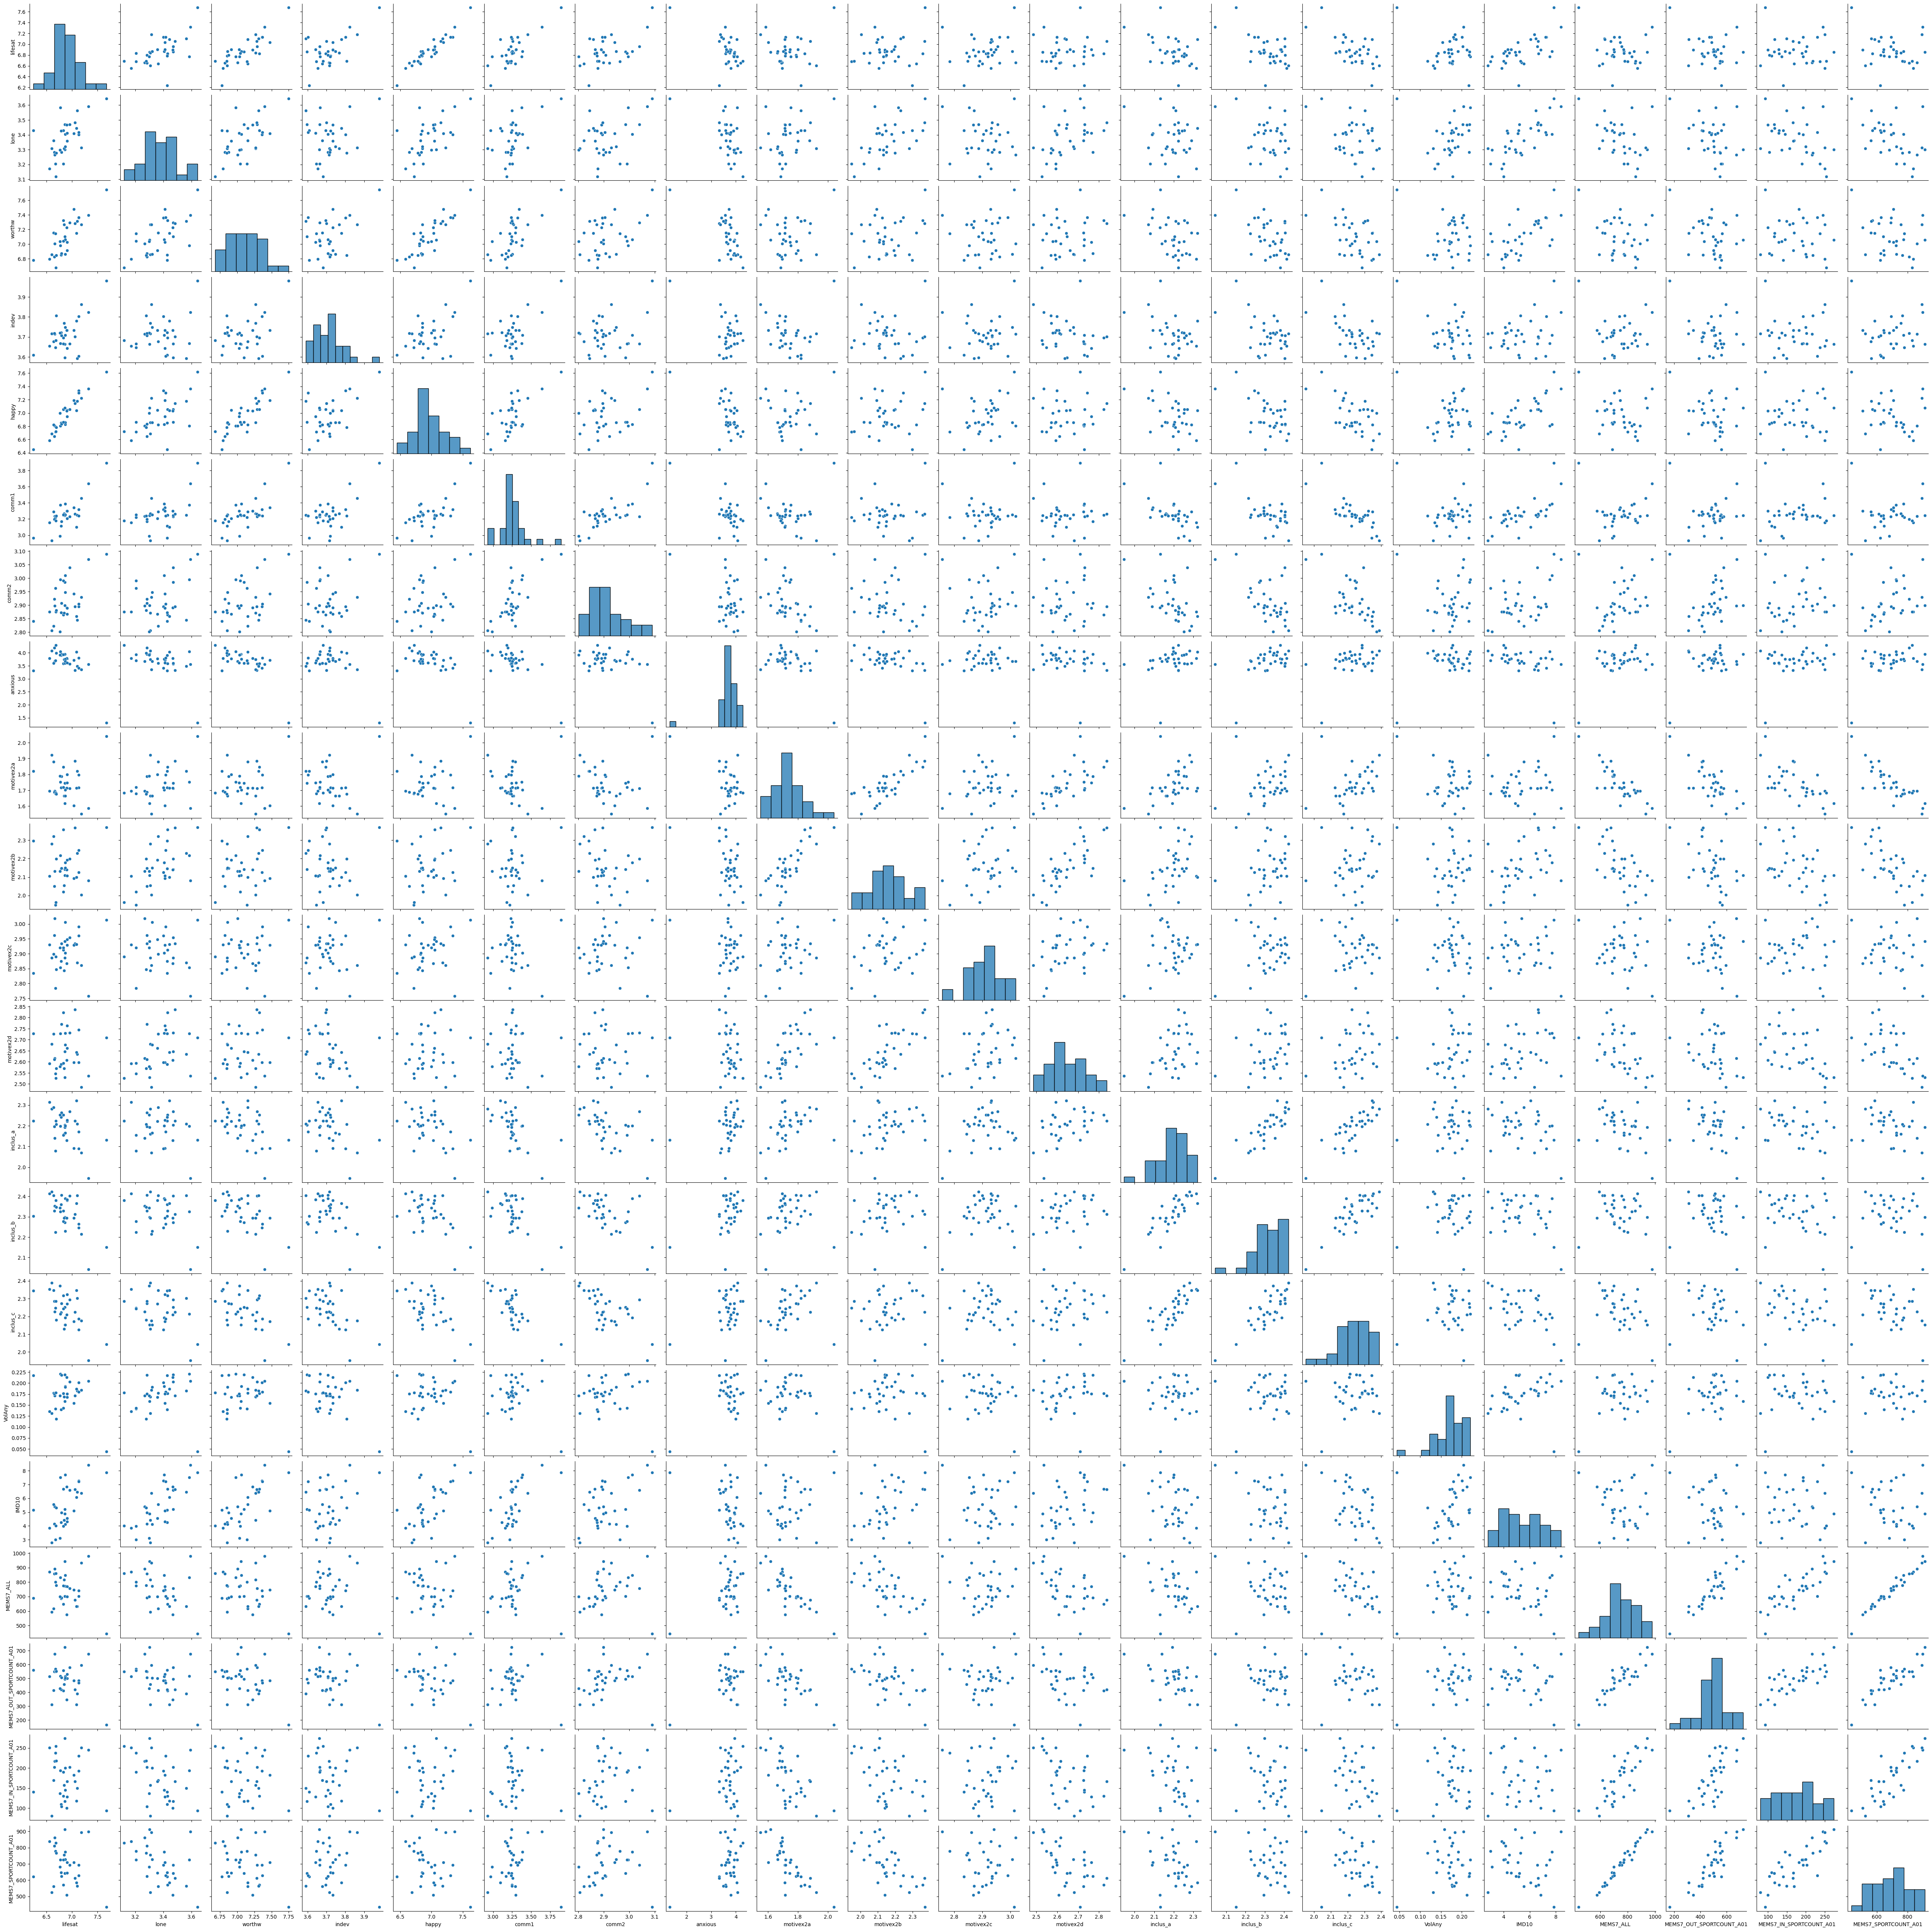

In [200]:

sns.pairplot(
    combined, 
    vars = features
)

In [240]:
green_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\greenSpaces2020.xlsx'
green = pd.read_excel(green_path, sheet_name = 'Urban LAD Parks Only', skiprows=1)
green.head()

,Country code,Country name,Region code,Region name,County code,County name,LAD code,LAD name,Average distance to nearest park or public garden (m),Median distance to nearest park or public garden (m),...,"Median combined size of parks or public gardens within 1,000 m radius (m2)",Population,Average population per park or public garden,Median population per park or public garden,Number of flats within built up area,Number of flats in built up area with gardens,Average garden size for flats in built up area,Number of houses within built up area,Number of houses in built up area with gardens,Average garden size for houses in built up area
0,E92000001,England,E12000001,North East,E11000007,Tyne and Wear,E08000021,Newcastle upon Tyne,358.720980,299.15213,...,295901.0,300196.0,8767.648352,7944.380651,52239.0,34570.340354,128.291506,80383.0,79553.0,167.524506
1,E92000001,England,E12000001,North East,E11000007,Tyne and Wear,E08000022,North Tyneside,473.777560,371.20615,...,130420.0,205985.0,8898.734546,9215.610627,24818.0,20352.819103,155.958369,74614.0,73559.0,171.593901
2,E92000001,England,E12000001,North East,E11000007,Tyne and Wear,E08000023,South Tyneside,398.688959,290.53793,...,365401.0,150265.0,8998.674553,8382.999001,16690.0,14798.523174,114.586942,55211.0,54600.0,167.570473
3,E92000001,England,E12000001,North East,E11000007,Tyne and Wear,E08000024,Sunderland,649.245587,500.00100,...,118070.0,277417.0,14889.726923,14517.632766,20307.0,13571.825745,176.945310,109518.0,108481.0,159.980452
4,E92000001,England,E12000001,North East,E11000007,Tyne and Wear,E08000037,Gateshead,460.870578,339.09440,...,212117.0,202508.0,7659.553651,7913.394863,22133.0,15614.995006,126.132788,69696.0,68275.0,174.734547


In [241]:
green.columns

Index(['Country code', 'Country name', 'Region code', 'Region name',
       'County code', 'County name', 'LAD code', 'LAD name',
       'Average distance to nearest park or public garden (m)',
       'Median distance to nearest park or public garden (m)',
       'Average size of nearest park or public garden (m2)',
       'Median size of nearest park or public garden (m2)',
       'Average number of parks or public gardens within 1,000 m radius',
       'Median number of parks or public gardens within 1,000 m radius',
       'Average combined size of parks or public gardens within 1,000 m radius (m2)',
       'Median combined size of parks or public gardens within 1,000 m radius (m2)',
       'Population ', 'Average population per park or public garden',
       'Median population per park or public garden',
       'Number of flats within built up area',
       'Number of flats in built up area with gardens',
       'Average garden size for flats in built up area',
       'Number of ho

In [242]:
cols = [
    'LAD code', 'LAD name',
    'Average distance to nearest park or public garden (m)', # focusses on accessibility and availability
    'Average number of parks or public gardens within 1,000 m radius',
    'Average combined size of parks or public gardens within 1,000 m radius (m2)' 
]
green = green[cols]
green = green.rename({
    'LAD code' : 'lad_code',
    'LAD name' : 'lad_name',
    'Average distance to nearest park or public garden (m)' : 'avg_dist_topark_m',
    'Average number of parks or public gardens within 1,000 m radius' : 'avg_num_park_w1000m',
    'Average combined size of parks or public gardens within 1,000 m radius (m2)' : 'avg_combsize_park_w1000m2'

}, axis=1)
green.head()

,lad_code,lad_name,avg_dist_topark_m,avg_num_park_w1000m,avg_combsize_park_w1000m2
0,E08000021,Newcastle upon Tyne,358.720980,5.690101,680146.025944
1,E08000022,North Tyneside,473.777560,3.253814,433838.118255
2,E08000023,South Tyneside,398.688959,4.593132,437293.649532
3,E08000024,Sunderland,649.245587,1.831195,225048.284502
4,E08000037,Gateshead,460.870578,4.918692,385365.633822


In [243]:
green.to_csv('green_spaces.csv', index=False)

In [223]:
crime_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\M1045_MonthlyCrimeDashboard_TNOCrimeData.xlsx'
crime = pd.read_excel(crime_path)

In [224]:
print(len(crime))
crime = crime[crime['Financial Year'] == 'fy22-23']
crime = crime[crime['Area Type'] == 'Borough']
print(len(crime))

862353
17189


In [225]:
crime.head()

,Month_Year,Area Type,Borough_SNT,Area name,Area code,Offence Group,Offence Subgroup,Measure,Financial Year,FY_FYIndex,Count,Refresh Date
0,2022-05-01,Borough,Barking and Dagenham,Barking and Dagenham,E09000002,ARSON AND CRIMINAL DAMAGE,ARSON,Offences,fy22-23,22-23_01,6,2026-05-02
1,2022-05-01,Borough,Barking and Dagenham,Barking and Dagenham,E09000002,ARSON AND CRIMINAL DAMAGE,CRIMINAL DAMAGE,Offences,fy22-23,22-23_01,111,2026-05-02
2,2022-05-01,Borough,Barking and Dagenham,Barking and Dagenham,E09000002,ARSON AND CRIMINAL DAMAGE,CRIMINAL DAMAGE,Positive Outcomes,fy22-23,22-23_01,8,2026-05-02
3,2022-05-01,Borough,Barking and Dagenham,Barking and Dagenham,E09000002,BURGLARY,BURGLARY - BUSINESS AND COMMUNITY,Offences,fy22-23,22-23_01,15,2026-05-02
4,2022-05-01,Borough,Barking and Dagenham,Barking and Dagenham,E09000002,BURGLARY,BURGLARY - BUSINESS AND COMMUNITY,Positive Outcomes,fy22-23,22-23_01,6,2026-05-02


In [226]:
crime['Area code'].unique()

<StringArray>
['E09000002', 'E09000003', 'E09000004', 'E09000005', 'E09000006', 'E09000007',
 'E09000008', 'E09000009', 'E09000010', 'E09000011', 'E09000012', 'E09000013',
 'E09000014', 'E09000015', 'E09000016', 'E09000017', 'E09000018', 'E09000019',
 'E09000020', 'E09000021', 'E09000022', 'E09000023', 'E09000024',         nan,
 'E09000025', 'E09000026', 'E09000027', 'E09000028', 'E09000029', 'E09000030',
 'E09000031', 'E09000032', 'E09000033']
Length: 33, dtype: str

In [227]:
lad_crime = crime.groupby(['Area name', 'Area code'])['Count'].count()
lad_crime

Area name               Area code
Barking and Dagenham    E09000002    498
Barnet                  E09000003    537
Bexley                  E09000004    495
Brent                   E09000005    537
Bromley                 E09000006    515
Camden                  E09000007    529
Croydon                 E09000008    523
Ealing                  E09000009    531
Enfield                 E09000010    520
Greenwich               E09000011    527
Hackney                 E09000012    526
Hammersmith and Fulham  E09000013    517
Haringey                E09000014    529
Harrow                  E09000015    495
Havering                E09000016    498
Hillingdon              E09000017    534
Hounslow                E09000018    515
Islington               E09000019    537
Kensington and Chelsea  E09000020    503
Kingston upon Thames    E09000021    467
Lambeth                 E09000022    540
Lewisham                E09000023    553
Merton                  E09000024    499
Newham                 

In [228]:
lad_crime = lad_crime.to_frame().reset_index()
lad_crime = lad_crime.rename({
    'Count' : 'crime_count'
}, axis=1)
lad_crime.head()

,Area name,Area code,crime_count
0,Barking and Dagenham,E09000002,498
1,Barnet,E09000003,537
2,Bexley,E09000004,495
3,Brent,E09000005,537
4,Bromley,E09000006,515


In [229]:
lad_crime = lad_crime.rename({
    'Area name' : 'lad_name',
    'Area code' : 'lad_code'
}, axis=1)
lad_crime.head()

,lad_name,lad_code,crime_count
0,Barking and Dagenham,E09000002,498
1,Barnet,E09000003,537
2,Bexley,E09000004,495
3,Brent,E09000005,537
4,Bromley,E09000006,515


In [230]:
lad_crime.to_csv('lad_crime.csv', index=False)

In [287]:
lads_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\london_lads.csv'
lads = pd.read_csv(lads_path)

In [288]:
LAD_CODES = lads['lad_code'].values
print(LAD_CODES)

<StringArray>
['E09000014', 'E09000017', 'E09000003', 'E09000018', 'E09000021', 'E09000024',
 'E09000025', 'E09000002', 'E09000006', 'E09000012', 'E09000016', 'E09000027',
 'E09000013', 'E09000022', 'E09000028', 'E09000033', 'E09000004', 'E09000007',
 'E09000008', 'E09000019', 'E09000023', 'E09000030', 'E09000001', 'E09000005',
 'E09000009', 'E09000011', 'E09000015', 'E09000026', 'E09000032', 'E09000010',
 'E09000020', 'E09000029', 'E09000031']
Length: 33, dtype: str


In [289]:
dataset_paths = [ 
    r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\green_spaces.csv', r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\active_operational_places.csv',
    r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\ethnic_diversity.csv', r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\lad_crime.csv',
    r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\pop_density.csv', r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\social_environmental.csv'
]
for i in dataset_paths:
    print(i)
    break

C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\green_spaces.csv


In [290]:
def check(df):
    for c in df.columns:
        if c != 'LA_2023':
            continue
        else:
            return True
    return False
for i in dataset_paths:
    print(f'starting dataset:\n{i}')
    x = pd.read_csv(i)
    if check(x):
        x = x.rename({'LA_2023' : 'id'}, axis=1)
        lads = pd.merge(lads, x, on='id', how='left')
        continue 
    lads = pd.merge(lads, x, on=['lad_name', 'lad_code'], how='left')
print(lads.columns)
lads.head()

starting dataset:
C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\green_spaces.csv
starting dataset:
C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\active_operational_places.csv
starting dataset:
C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\ethnic_diversity.csv
starting dataset:
C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\lad_crime.csv
starting dataset:
C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\pop_density.csv
starting dataset:
C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\social_environmental.csv
Index(['id', 'lad_code', 'lad_name', 'avg_dist_topark_m',
       'avg_num_park_w1000m', 'avg_combsize_park_w1000m2', 'status',
       'total_pop', 'asian', 'black', 'mixed', 'white', 'other',
       'simpsons_index', 'crime_count', 'pop_per_km2', 'lifesat', 'lone',
       'worthw', 'indev

,id,lad_code,lad_name,avg_dist_topark_m,avg_num_park_w1000m,avg_combsize_park_w1000m2,status,total_pop,asian,black,...,motivex2d,inclus_a,inclus_b,inclus_c,VolAny,IMD10,MEMS7_ALL,MEMS7_OUT_SPORTCOUNT_A01,MEMS7_IN_SPORTCOUNT_A01,MEMS7_SPORTCOUNT_A01
0,114.0,E09000014,Haringey,318.273817,6.249303,4.327196e+05,276,264238,0.087345,0.175849,...,2.570577,2.160622,2.293963,2.129870,0.168269,4.419173,814.960056,456.741627,157.631579,755.865132
1,126.0,E09000017,Hillingdon,590.904034,2.489399,3.242326e+05,469,305907,0.333232,0.078308,...,2.635165,2.209302,2.403561,2.302671,0.182292,6.467347,631.632653,390.374332,149.625668,563.293878
2,9.0,E09000003,Barnet,390.896848,3.431073,5.002587e+05,512,389344,0.192560,0.078725,...,2.731183,2.269006,2.403030,2.293769,0.202703,6.601227,757.796524,579.083784,202.371622,692.212679
3,129.0,E09000018,Hounslow,429.466688,2.828353,6.491325e+05,423,288181,0.367290,0.072212,...,2.770065,2.263930,2.405325,2.272727,0.218421,4.959016,692.987193,505.404570,104.014785,624.739242
4,139.0,E09000021,Kingston upon Thames,738.994773,1.601615,2.490337e+06,275,168065,0.178133,0.028209,...,2.729897,2.200000,2.388406,2.191977,0.192208,7.712575,846.763972,514.517949,145.256410,773.523952


In [296]:
lads.isna().sum()

id                           0
lad_code                     0
lad_name                     0
avg_dist_topark_m            0
avg_num_park_w1000m          0
avg_combsize_park_w1000m2    0
status                       0
total_pop                    0
asian                        0
black                        0
mixed                        0
white                        0
other                        0
simpsons_index               0
crime_count                  1
pop_per_km2                  0
lifesat                      0
lone                         0
worthw                       0
indev                        0
happy                        0
comm1                        0
comm2                        0
anxious                      0
motivex2a                    0
motivex2b                    0
motivex2c                    0
motivex2d                    0
inclus_a                     0
inclus_b                     0
inclus_c                     0
VolAny                       0
IMD10   

In [ ]:
len(lads)
# lads.to_csv('borough_profiles.csv', index=False)

In [293]:
borough_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\borough_profiles.csv'
boroughs = pd.read_csv(borough_path)


In [299]:
boroughs.columns

Index(['id', 'lad_code', 'lad_name', 'avg_dist_topark_m',
       'avg_num_park_w1000m', 'avg_combsize_park_w1000m2', 'status',
       'total_pop', 'asian', 'black', 'mixed', 'white', 'other',
       'simpsons_index', 'crime_count', 'pop_per_km2', 'lifesat', 'lone',
       'worthw', 'indev', 'happy', 'comm1', 'comm2', 'anxious', 'motivex2a',
       'motivex2b', 'motivex2c', 'motivex2d', 'inclus_a', 'inclus_b',
       'inclus_c', 'VolAny', 'IMD10', 'MEMS7_ALL', 'MEMS7_OUT_SPORTCOUNT_A01',
       'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_SPORTCOUNT_A01'],
      dtype='str')

In [300]:
pca_cols = [
        'avg_dist_topark_m',
       'avg_num_park_w1000m', 'avg_combsize_park_w1000m2', 'status',
       'simpsons_index', 'crime_count', 'pop_per_km2', 'lifesat', 'lone',
       'worthw', 'indev', 'happy', 'comm1', 'comm2', 'anxious', 'motivex2a',
       'motivex2b', 'motivex2c', 'motivex2d', 'inclus_a', 'inclus_b',
       'inclus_c', 'VolAny', 'IMD10', 'MEMS7_ALL', 'MEMS7_OUT_SPORTCOUNT_A01',
       'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_SPORTCOUNT_A01'
]
boroughs = boroughs[pca_cols]
boroughs = boroughs.fillna(boroughs.mean())

In [ ]:


scaler = StandardScaler()
X  = boroughs.values
X_scaled = scaler.fit_transform(X)
pca = PCA()
emb = pca.fit_transform(X_scaled)

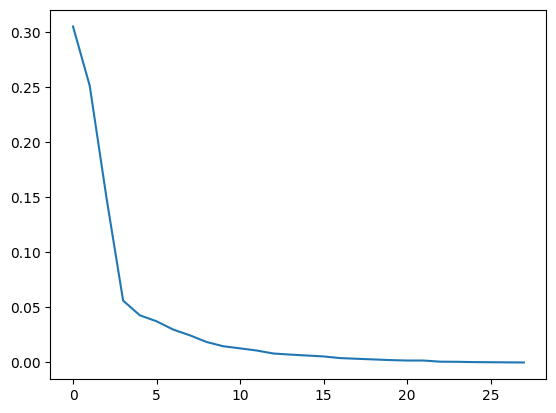

In [302]:
import matplotlib.pyplot as plt
plt.plot(pca.explained_variance_ratio_)

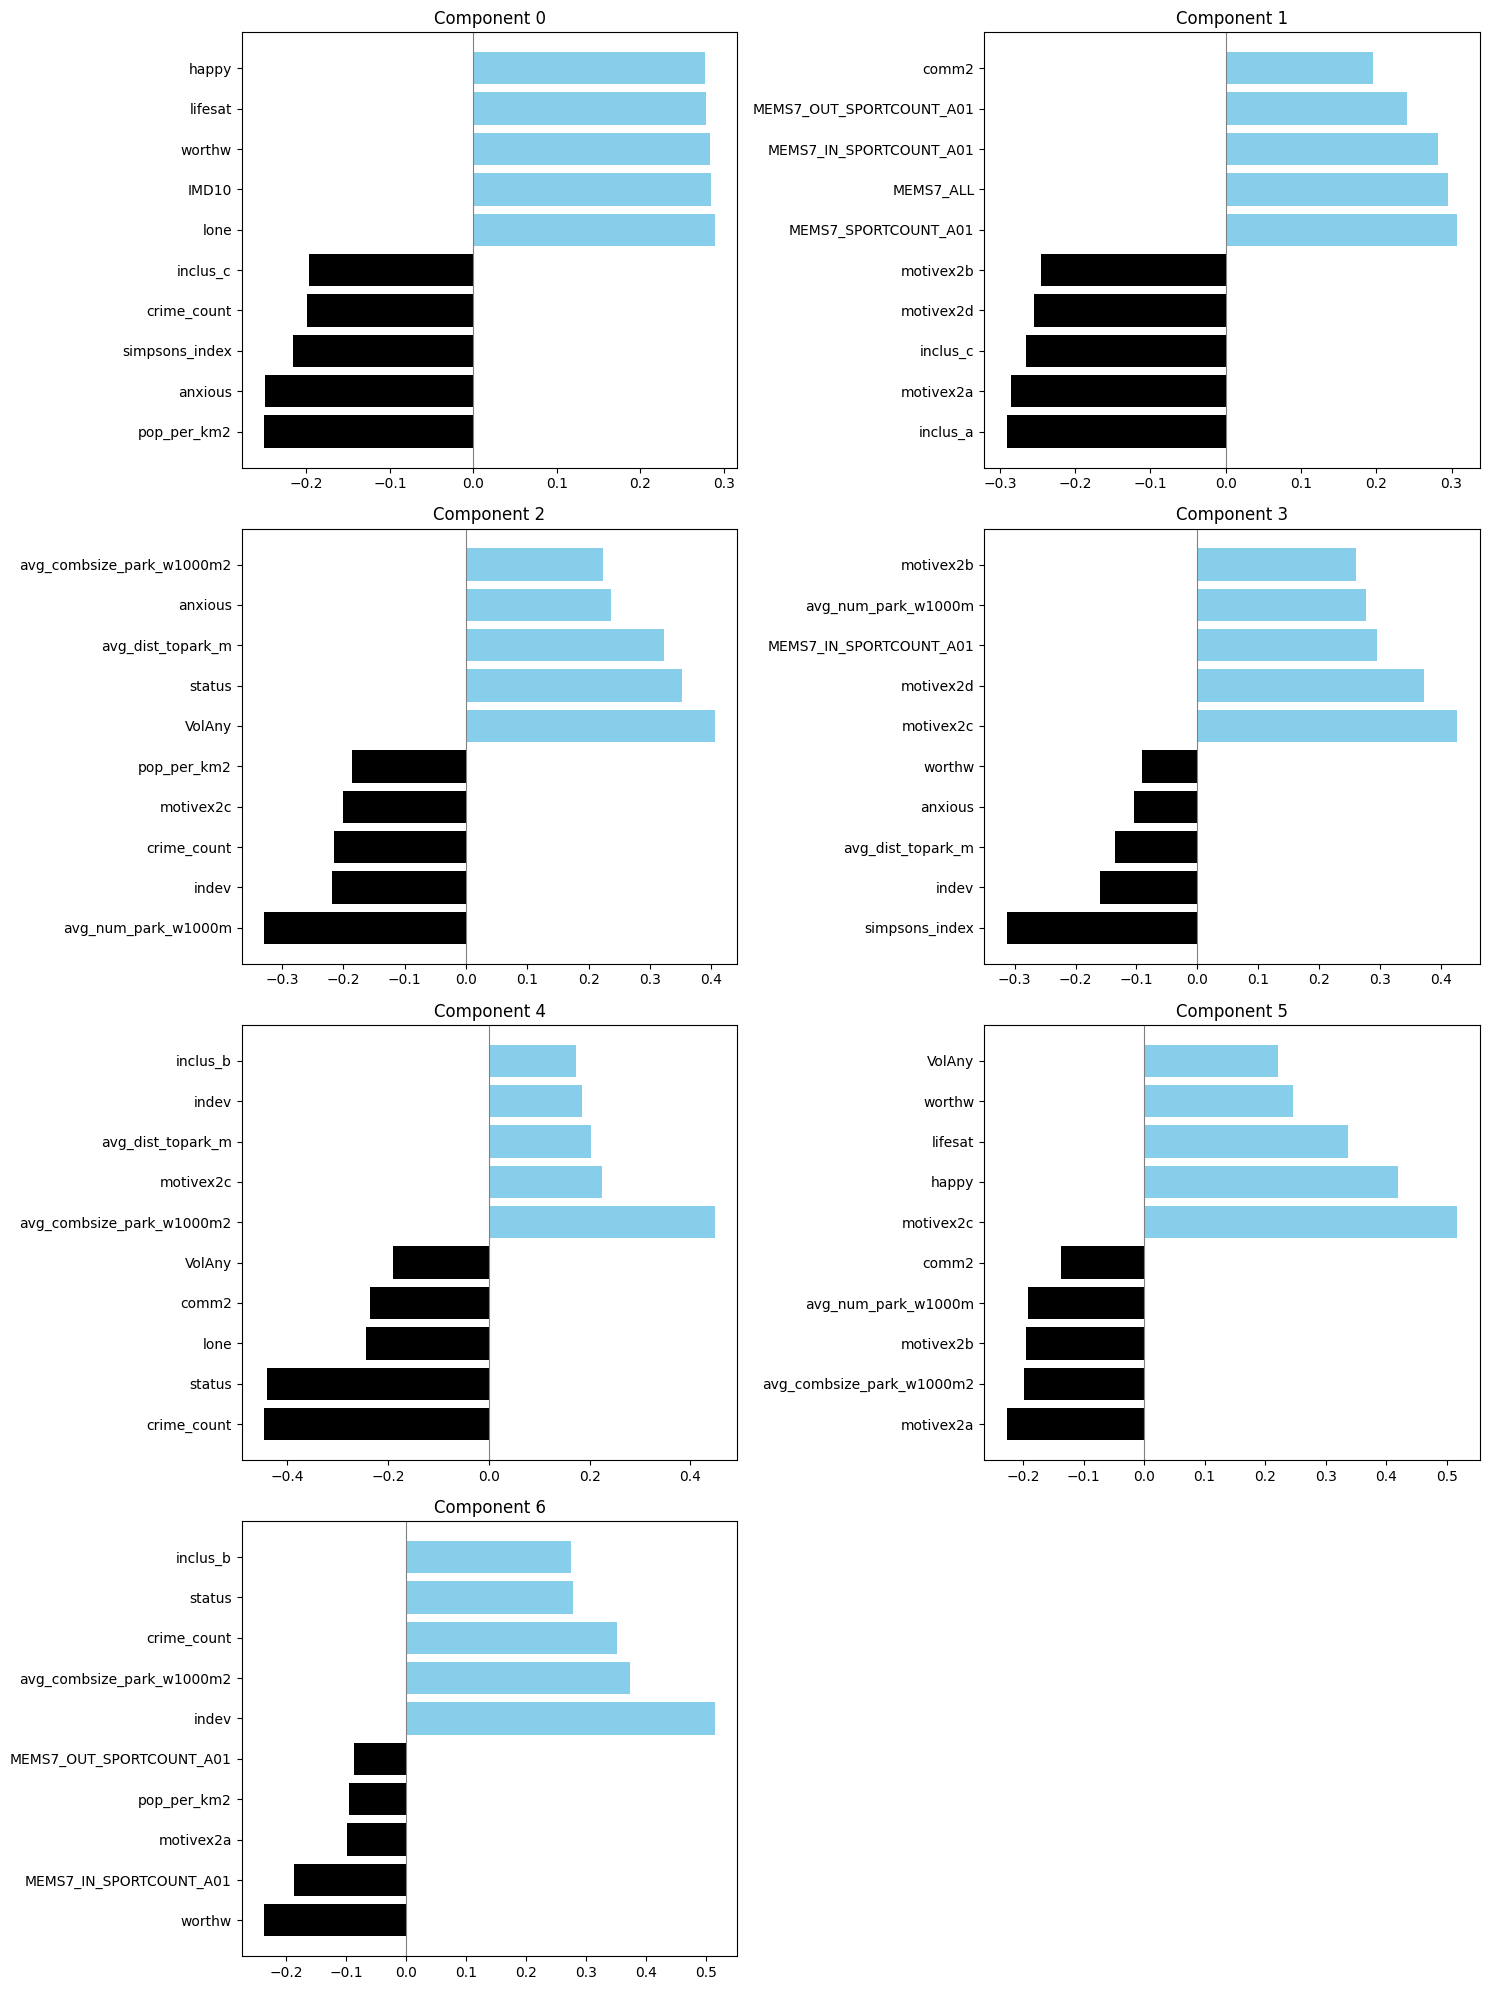

In [305]:
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

for c in range(8):
    s = pd.Series(pca.components_[c], index=boroughs.columns)
    combined = pd.concat([s.sort_values().head(5), s.sort_values(ascending=False).head(5)])
    colors = ['black' if v < 0 else 'skyblue' for v in combined.values]
    axes[c].barh(combined.index, combined.values, color=colors)
    axes[c].set_title(f'Component {c}')
    axes[c].axvline(x=0, color='grey', linewidth=0.8)

axes[7].set_visible(False)
plt.tight_layout()
plt.show()

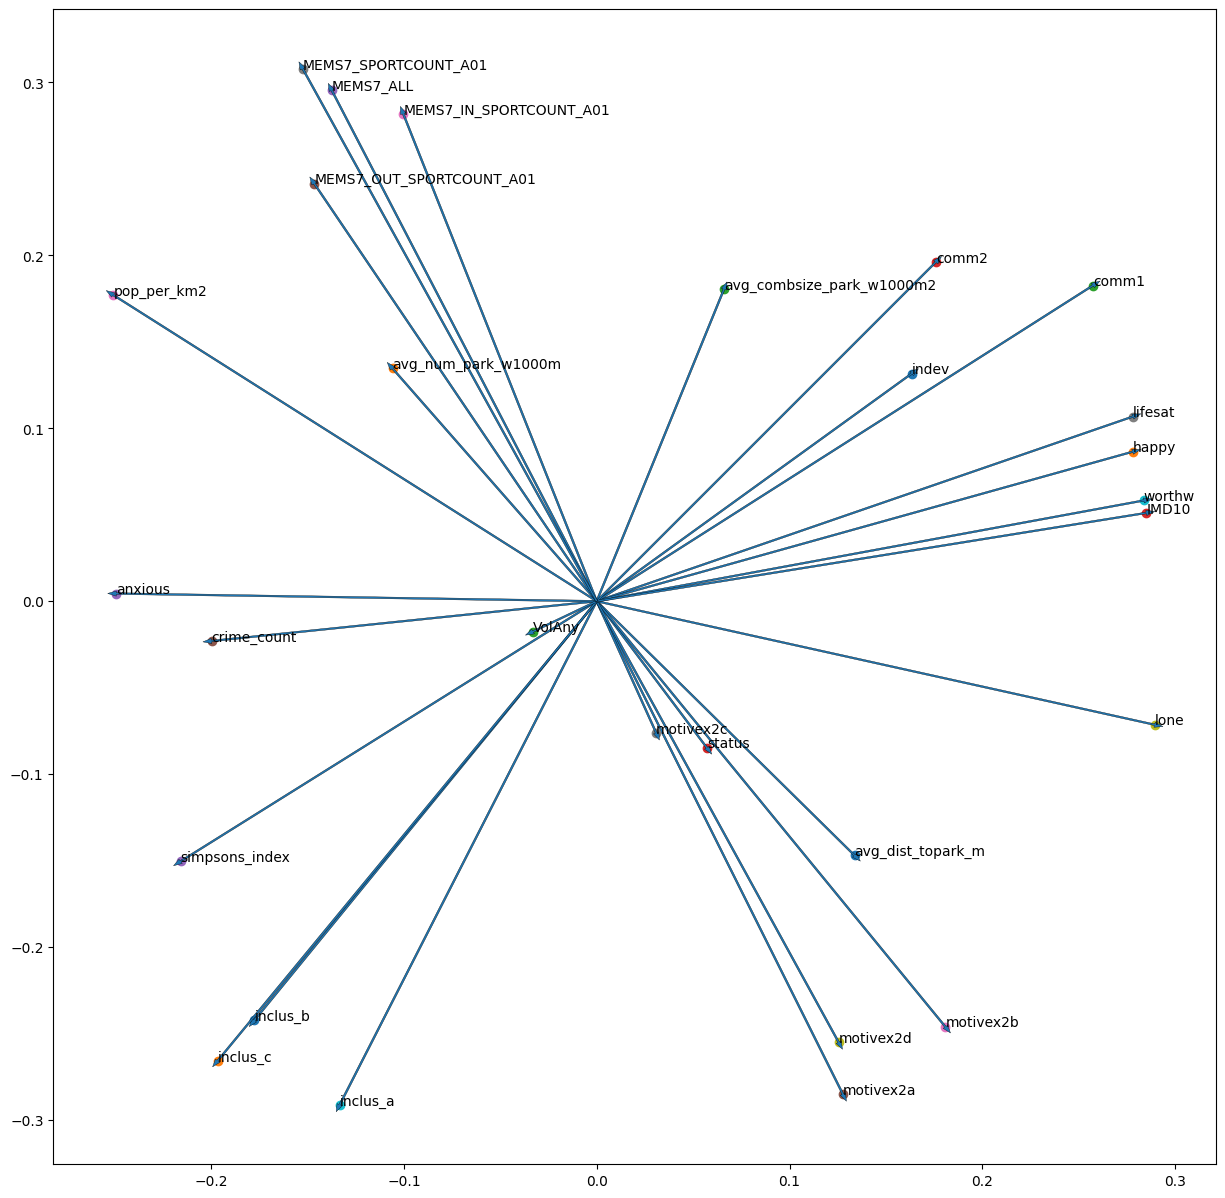

In [318]:
plt.figure(figsize=(15,15))
loadings = pca.components_
xs = loadings[0]
ys = loadings[1]
feature_names = boroughs.columns
for i, names in enumerate(feature_names):
    plt.scatter(xs[i], ys[i])
    plt.arrow(
        0, 0, 
        xs[i],
        ys[i],
        linewidth = 0.25
    )
    plt.text(xs[i], ys[i], names)

0
1
2
3
4
5
6
7


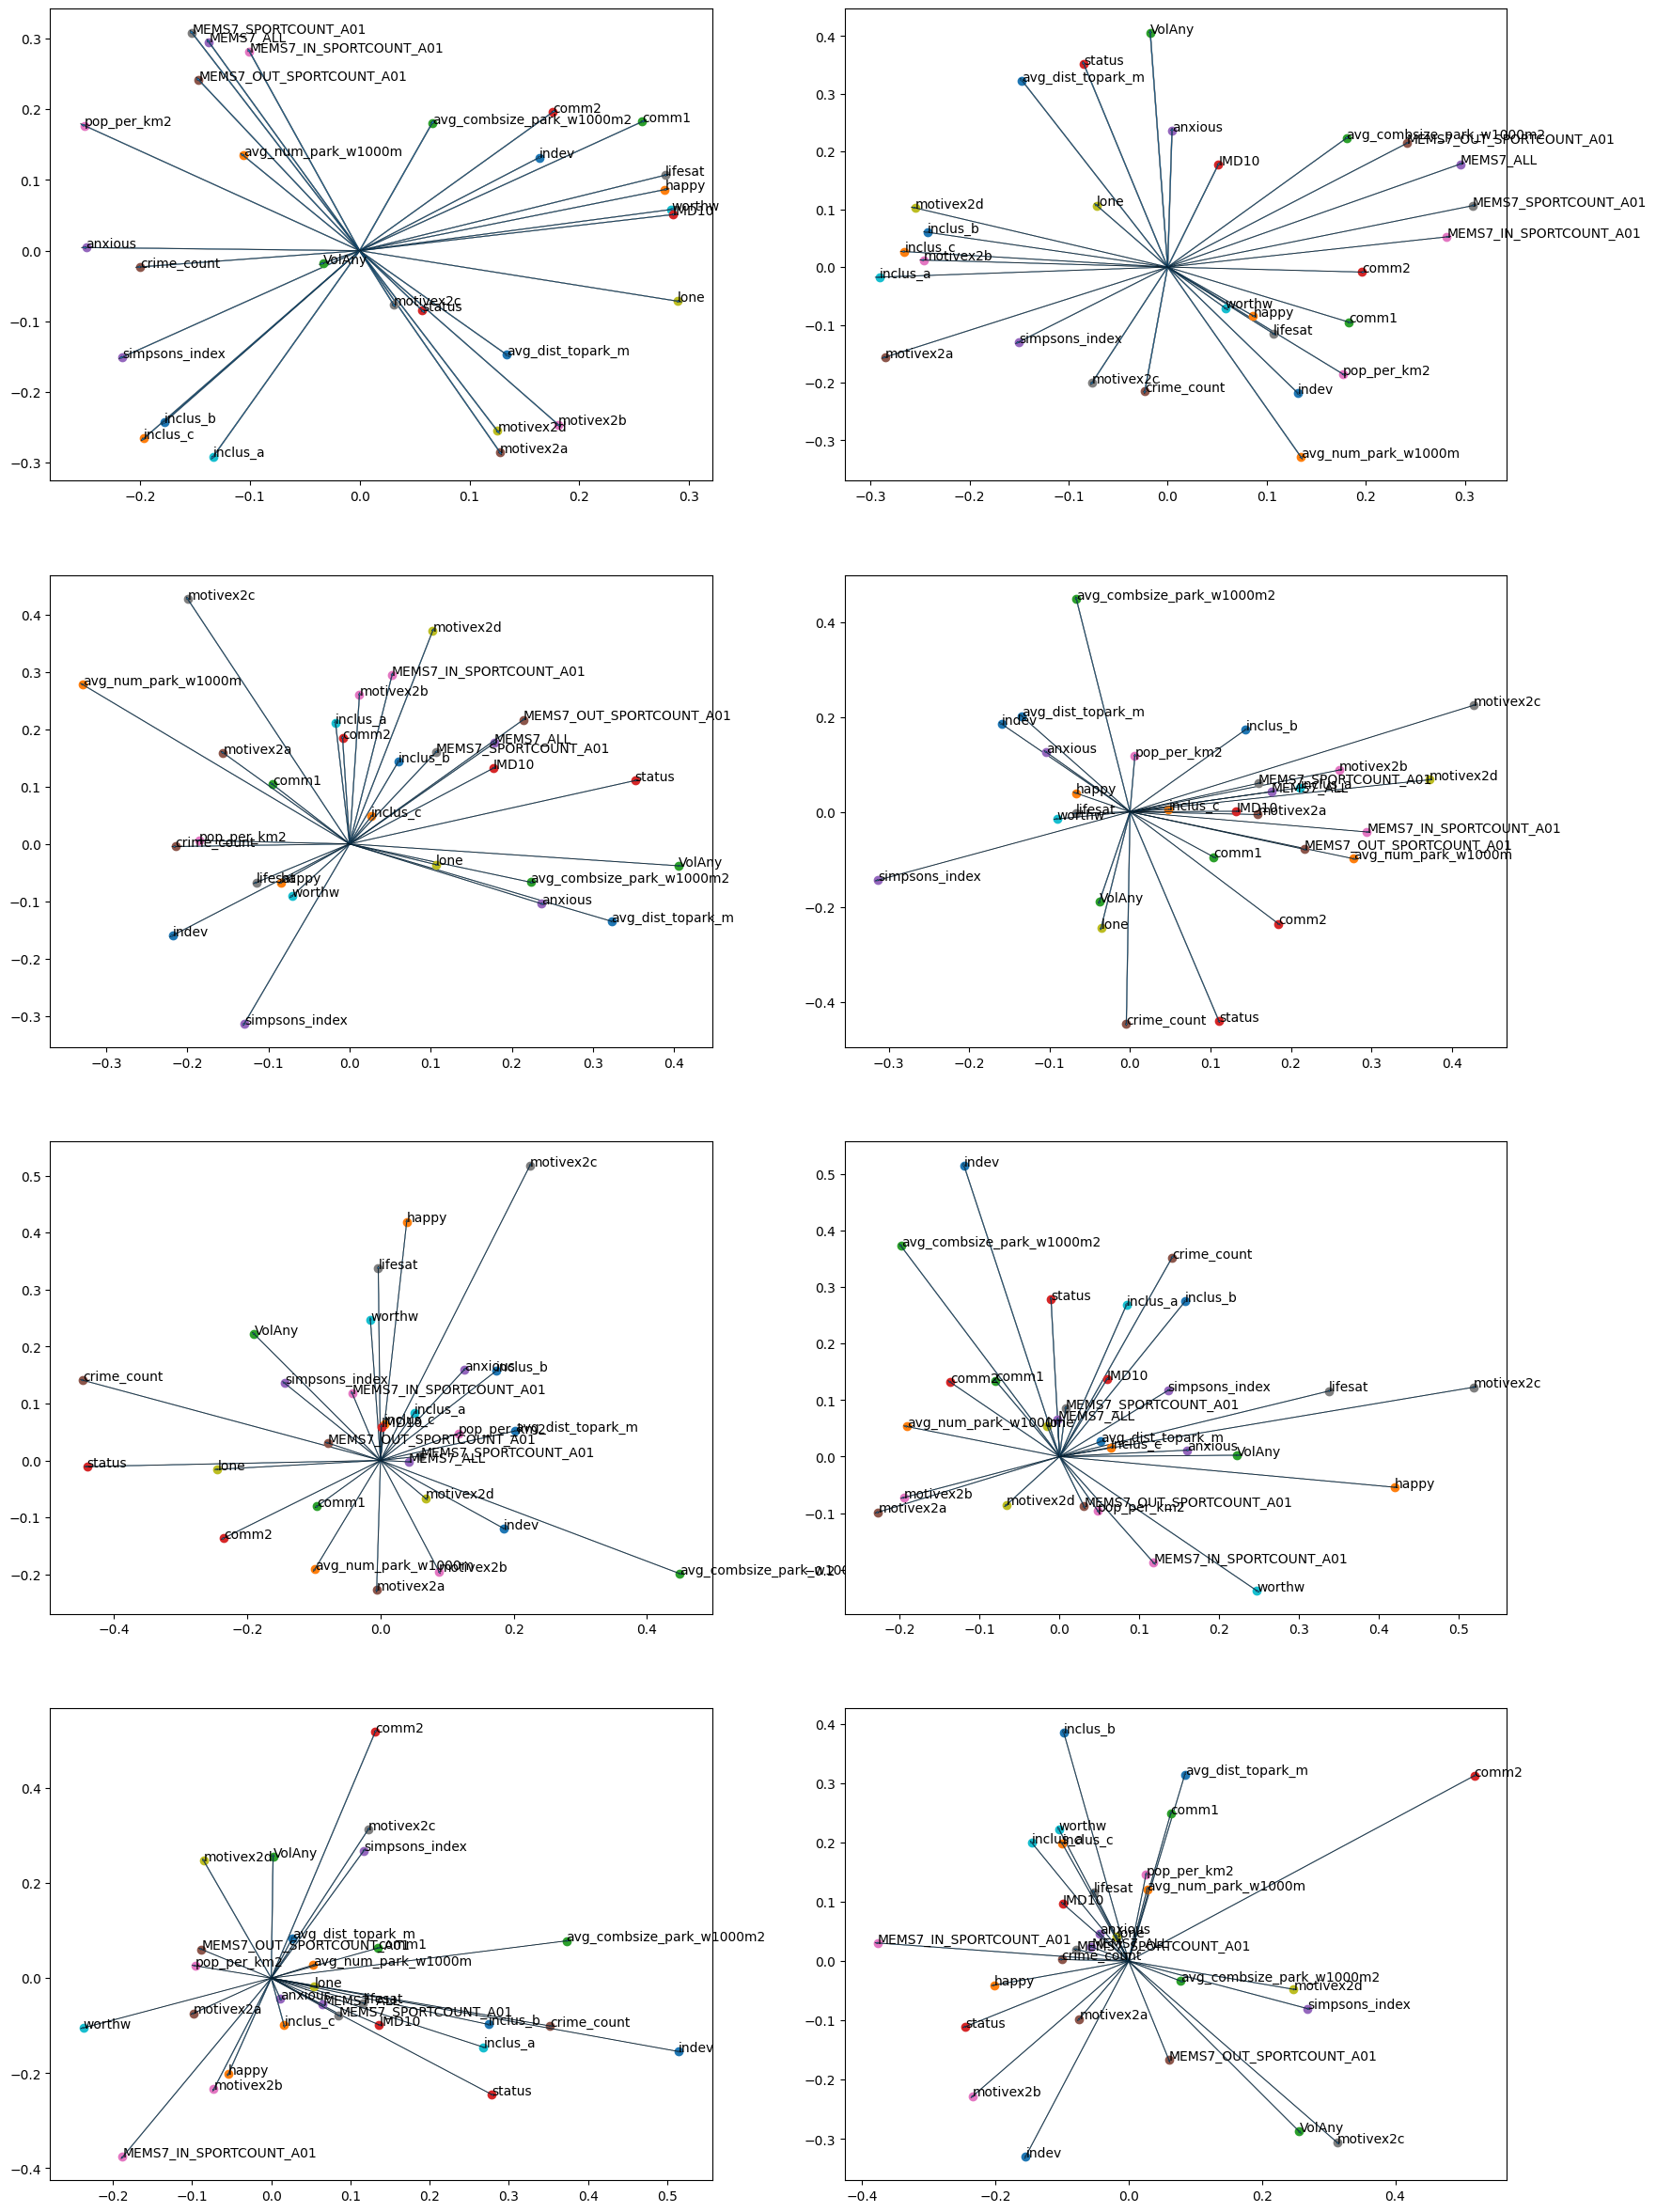

In [330]:

def gen_plots():
    fig, axes = plt.subplots(4, 2, figsize=(20, 30))
    axes = axes.flatten()
    for idx in range(8):
        if idx > 7:
            return 'done'
        print(idx)
        xs = loadings[idx]
        ys = loadings[idx+1]
        feature_names = boroughs.columns
        for i, names in enumerate(feature_names):
            axes[idx].scatter(xs[i], ys[i])
            axes[idx].arrow(
                0, 0, 
                xs[i],
                ys[i],
                linewidth = 0.25
            )
            axes[idx].text(xs[i], ys[i], names)

gen_plots()

In [312]:
for i, v in enumerate(loadings):
    print(i)
    print(v)
    break

0
[ 0.13369584 -0.10586864  0.06600954  0.05712657 -0.21576991 -0.1997376
 -0.25069143  0.27800144  0.28928618  0.28367662  0.16333767  0.27785667
  0.25729117  0.17581738 -0.24910215  0.12765321  0.18079982  0.03083407
  0.12546979 -0.13324424 -0.17754794 -0.19651925 -0.03299849  0.28498823
 -0.1373566  -0.14647078 -0.10032881 -0.15244979]


Data Collected...
Data Shape: (16748, 116)
11369


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


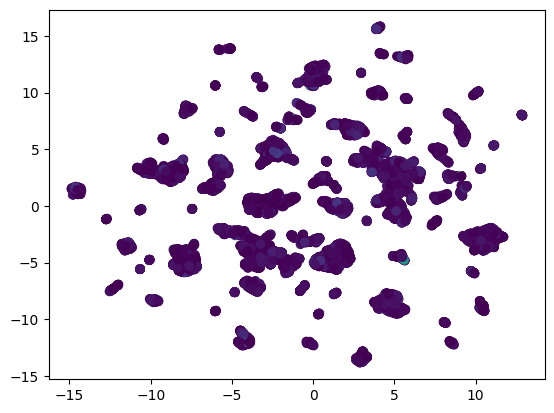

In [111]:
df, meta = get_2022_data()
demographic_cols = ['Gend3', 'Disab3', 'Age9', 'Eth7','NSSEC5']
other_cols = ['Educ6','DVBMI', 'IMD10']
duration_cols = ['MEMS7_ALL']
cols = demographic_cols + other_cols + duration_cols
df = df[cols]
df = df.dropna()
umap_df_encoded = pd.get_dummies(df, columns=['Gend3', 'Disab3','Eth7'])
print(len(umap_df_encoded))

def do_umap(df_values, random_state: int = 42):
    reduce = umap.UMAP(random_state = random_state)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_values)
    emb = reduce.fit_transform(X_scaled)
    return emb
mems = df['MEMS7_ALL'].values
exclude = 'MEMS7_ALL'
umap_cols = [c for c in umap_df_encoded.columns if c != exclude]
umap_values = umap_df_encoded[umap_cols].values
emb = do_umap(umap_values)
plt.scatter(emb[:,0], emb[:,1], c=mems)

In [218]:
df, meta = get_2022_data()

Data Collected...
Data Shape: (16748, 116)


In [219]:
demographic_cols = ['Gend3', 'Disab3', 'Age9', 'Eth7','NSSEC5']
other_cols = ['Educ6','IMD10', 'happy', 'lifesat', 'worthw', 'lone']
duration_cols = ['MEMS7_ALL']
cols = demographic_cols + other_cols + duration_cols
df = df[cols]
df = df.dropna()
umap_df_encoded = pd.get_dummies(df, columns=['Gend3', 'Disab3','Eth7'])
print(len(umap_df_encoded))
umap_df_encoded.head()


5181


,Age9,NSSEC5,Educ6,IMD10,happy,lifesat,worthw,lone,MEMS7_ALL,Gend3_1.0,...,Disab3_1.0,Disab3_2.0,Disab3_3.0,Eth7_1.0,Eth7_2.0,Eth7_3.0,Eth7_4.0,Eth7_5.0,Eth7_6.0,Eth7_7.0
54,6.0,3.0,1.0,4.0,7.0,7.0,7.0,4.0,0.0,True,...,True,False,False,True,False,False,False,False,False,False
55,7.0,4.0,5.0,8.0,0.0,0.0,0.0,1.0,0.0,False,...,True,False,False,True,False,False,False,False,False,False
58,4.0,1.0,1.0,3.0,8.0,8.0,10.0,3.0,6870.0,False,...,False,False,True,True,False,False,False,False,False,False
81,4.0,1.0,1.0,2.0,6.0,7.0,8.0,4.0,690.0,False,...,False,False,True,False,False,False,False,False,False,True
82,4.0,4.0,1.0,5.0,9.0,2.0,10.0,2.0,240.0,False,...,False,False,True,False,False,False,True,False,False,False


In [220]:
def do_umap(df_values, random_state: int = 42):
    reduce = umap.UMAP(random_state = random_state)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df_values)
    emb = reduce.fit_transform(X_scaled)
    return emb
mems = df['MEMS7_ALL'].values
exclude = 'MEMS7_ALL'
umap_cols = [c for c in umap_df_encoded.columns if c != exclude]
umap_values = umap_df_encoded[umap_cols].values
emb = do_umap(umap_values)

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


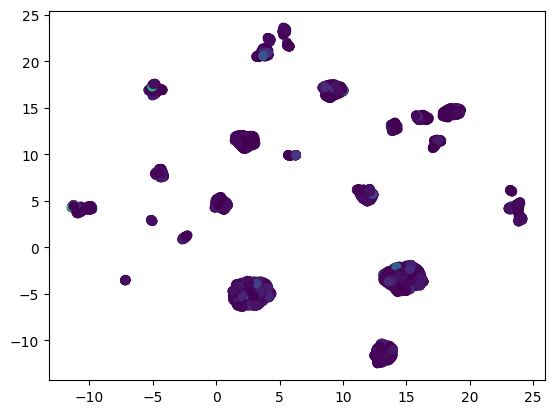

In [221]:
plt.scatter(emb[:,0], emb[:,1], c=mems)


In [222]:
emb.shape

(5181, 2)

In [223]:
def gen_clusters(emb, min_cluster_size) -> pd.DataFrame:
    c = hdbscan.HDBSCAN(min_cluster_size = min_cluster_size)
    labels = c.fit_predict(emb)
    df = pd.DataFrame({
        'umap_x' : emb[:, 0],
        'umap_y' : emb[:, 1],
        'labels' : labels
    })
    print(f'HDBSCAN has identified {len(set(labels))} clusters.')
    return df, labels
cluster_df, labels = gen_clusters(emb, min_cluster_size = 50)

HDBSCAN has identified 20 clusters.


In [224]:
cluster_df.head()

,umap_x,umap_y,labels
0,16.072800,14.078978,8
1,17.863499,14.368264,9
2,3.748934,-5.644272,5
3,-4.956331,16.430620,2
4,3.775733,21.294716,18


(np.float64(-13.1947585105896),
 np.float64(25.928898906707765),
 np.float64(-14.290542078018188),
 np.float64(25.45123906135559))

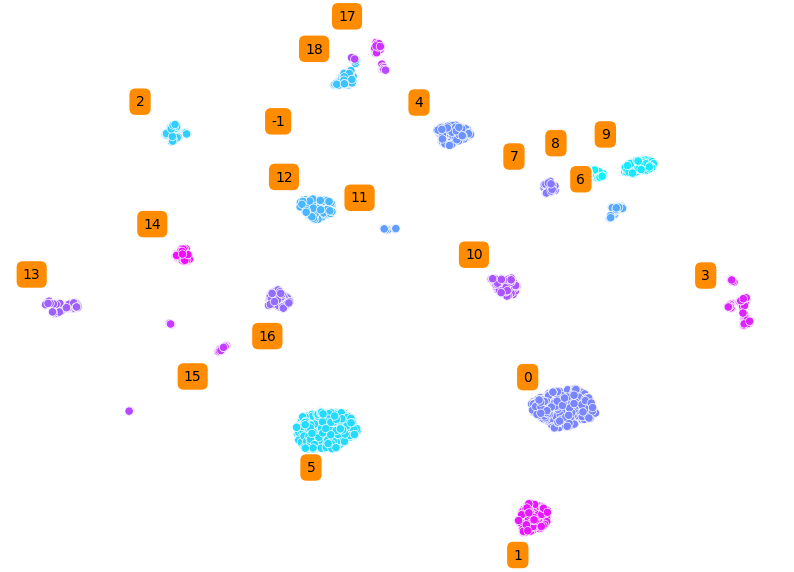

In [225]:
plt.figure(figsize=(10,7))
x_means = []
y_means = []
for l in sorted(cluster_df['labels'].unique()):
    l = int(l)
    mean = cluster_df[cluster_df['labels'] == l]
    x_means.append(mean['umap_x'].mean())
    y_means.append(mean['umap_y'].mean())

sns.scatterplot(
    x=emb[:,0],
    y=emb[:,1],
    hue=labels.astype(str),
    palette='cool',
    legend = False,
)
for idx, l in enumerate(sorted(cluster_df['labels'].unique())):
    if l == 16 or l == 15 or l == 5 or l == 1:
        plt.text(x_means[idx] - 1, y_means[idx] - 3,s=f'{l}',
             bbox=dict(
                boxstyle='round, pad=0.5',
                facecolor='darkorange',
                edgecolor= 'white' 
             ))
    else:
        plt.text(x_means[idx] - 2, y_means[idx] + 2,s=f'{l}',
                bbox=dict(
                    boxstyle='round, pad=0.5',
                    facecolor = 'darkorange',
                    edgecolor='white' 
                ))
plt.axis('off')

(np.float64(-13.1947585105896),
 np.float64(25.928898906707765),
 np.float64(-14.290542078018188),
 np.float64(25.45123906135559))

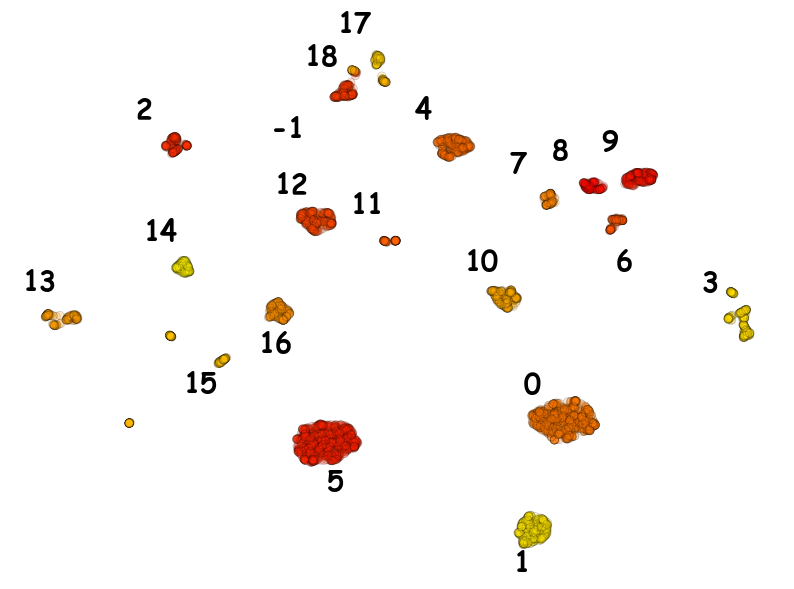

In [238]:
plt.figure(figsize=(10,7))
x_means = []
y_means = []
for l in sorted(cluster_df['labels'].unique()):
    l = int(l)
    mean = cluster_df[cluster_df['labels'] == l]
    x_means.append(mean['umap_x'].mean())
    y_means.append(mean['umap_y'].mean())

sns.scatterplot(
    x=emb[:,0],
    y=emb[:,1],
    hue=labels.astype(str),
    palette='autumn', # Wistia
    legend = False,
    alpha=0.2,
    edgecolor='black'
)
for idx, l in enumerate(sorted(cluster_df['labels'].unique())):
    if l == 16 or l == 15 or l == 1:
        plt.text(x_means[idx] - 1, y_means[idx] - 3,s=f'{l}',
                 fontsize=20,
                 weight='bold',
                 fontname ='cursive')
    elif l == 6 or l == 5:
        plt.text(x_means[idx], y_means[idx]-3.5, s=f'{l}',
                 fontsize=20,
                 weight='bold',
                 fontname ='cursive')
    else:
        plt.text(x_means[idx] - 2, y_means[idx] + 2,s=f'{l}',
                 fontsize=20,
                 weight='bold',
                 fontname = 'cursive')
plt.axis('off')

In [239]:
df['labels'] = labels
df.head()

,Gend3,Disab3,Age9,Eth7,NSSEC5,Educ6,IMD10,happy,lifesat,worthw,lone,MEMS7_ALL,labels
54,1.0,1.0,6.0,1.0,3.0,1.0,4.0,7.0,7.0,7.0,4.0,0.0,8
55,2.0,1.0,7.0,1.0,4.0,5.0,8.0,0.0,0.0,0.0,1.0,0.0,9
58,2.0,3.0,4.0,1.0,1.0,1.0,3.0,8.0,8.0,10.0,3.0,6870.0,5
81,2.0,3.0,4.0,7.0,1.0,1.0,2.0,6.0,7.0,8.0,4.0,690.0,2
82,2.0,3.0,4.0,4.0,4.0,1.0,5.0,9.0,2.0,10.0,2.0,240.0,18


In [240]:
eth = df.groupby(['labels', 'Eth7'])['Eth7'].sum()
eth

labels  Eth7
-1      1.0        8.0
        2.0       18.0
        3.0       18.0
        4.0      304.0
 0      1.0      805.0
 1      2.0      904.0
 2      7.0     1141.0
 3      6.0     1452.0
 4      3.0      981.0
 5      1.0      882.0
 6      2.0      212.0
 7      3.0      300.0
 8      1.0      120.0
 9      1.0      242.0
 10     2.0      554.0
 11     3.0      189.0
 12     3.0     1002.0
 13     5.0      845.0
 14     1.0      172.0
        2.0        2.0
 15     2.0      234.0
 16     1.0      243.0
 17     4.0      360.0
 18     4.0      708.0
Name: Eth7, dtype: float64

In [242]:
profiles = df.groupby('labels').agg({
    'Age9' : 'mean',
    'NSSEC5' : 'mean',
    'Educ6' : 'mean',
    'happy' : 'mean',
    'lifesat' : 'mean',
    'worthw' : 'mean',
    'lone' : 'mean',
    'MEMS7_ALL' : 'mean'
})

In [243]:
profiles.sort_values('MEMS7_ALL')

,Age9,NSSEC5,Educ6,happy,lifesat,worthw,lone,MEMS7_ALL
labels,,,,,,,,
7,4.610000,1.930000,2.120000,5.080000,5.080000,5.640000,2.260000,422.165000
9,4.971074,1.657025,2.115702,5.334711,5.330579,5.917355,2.760331,489.561983
12,4.026946,1.817365,1.823353,7.233533,7.161677,7.239521,3.323353,545.693862
-1,4.434343,1.969697,2.303030,5.777778,5.686869,6.272727,2.696970,545.931818
17,4.233333,2.033333,1.800000,7.722222,7.522222,7.466667,3.644444,608.808333
13,3.869822,1.656805,1.248521,6.940828,6.698225,7.035503,3.284024,680.403846
8,5.433333,1.558333,2.025000,5.858333,5.666667,5.833333,2.816667,713.885417
6,4.792453,1.622642,1.547170,5.622642,5.330189,6.415094,2.735849,715.186321
11,4.190476,1.634921,1.571429,6.873016,7.095238,7.222222,3.412698,734.198413


<Axes: >

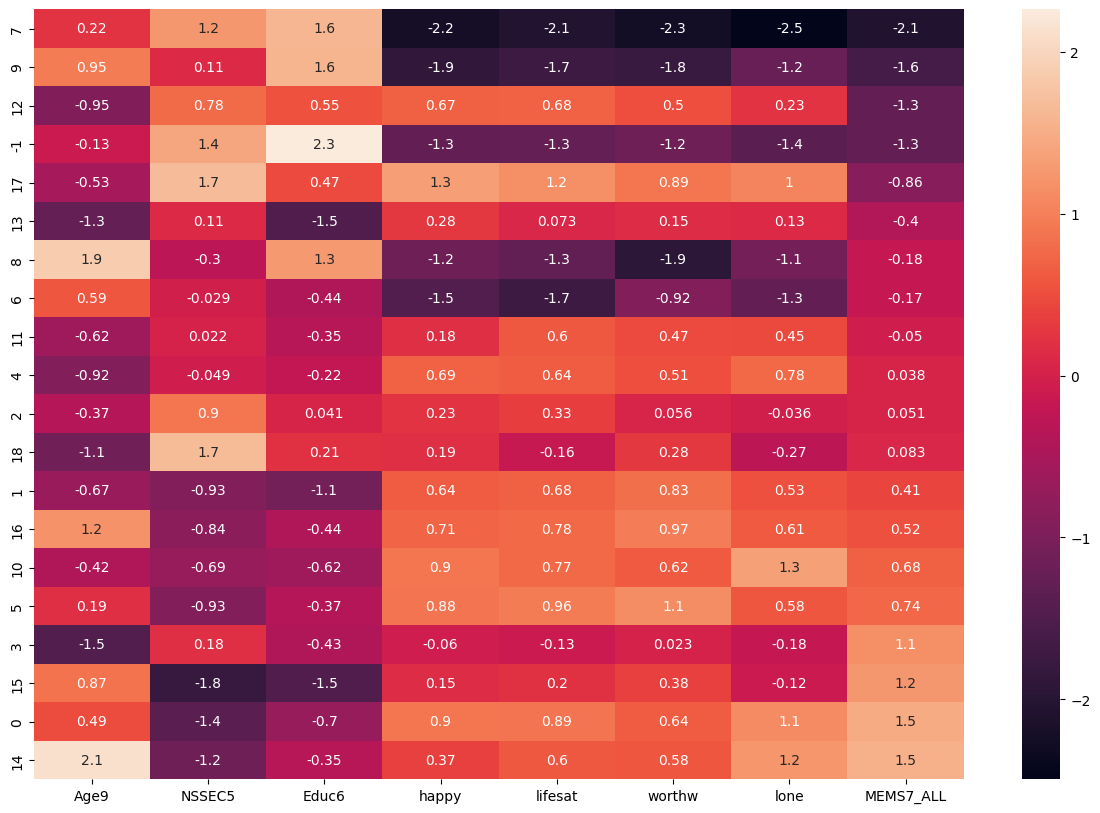

In [244]:
scaler = StandardScaler()
sorted_profiles = profiles.sort_values('MEMS7_ALL')
heat = scaler.fit_transform(sorted_profiles)
plt.figure(figsize=(15,10))
sns.heatmap(
    heat,
    annot=True,
    xticklabels = sorted_profiles.columns,
    yticklabels = sorted_profiles.index)

In [140]:
env_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\borough_profiles.csv'
env = pd.read_csv(env_path)


In [141]:
env.columns

Index(['id', 'lad_code', 'lad_name', 'avg_dist_topark_m',
       'avg_num_park_w1000m', 'avg_combsize_park_w1000m2', 'status',
       'total_pop', 'asian', 'black', 'mixed', 'white', 'other',
       'simpsons_index', 'crime_count', 'pop_per_km2', 'lifesat', 'lone',
       'worthw', 'indev', 'happy', 'comm1', 'comm2', 'anxious', 'motivex2a',
       'motivex2b', 'motivex2c', 'motivex2d', 'inclus_a', 'inclus_b',
       'inclus_c', 'VolAny', 'IMD10', 'MEMS7_ALL', 'MEMS7_OUT_SPORTCOUNT_A01',
       'MEMS7_IN_SPORTCOUNT_A01', 'MEMS7_SPORTCOUNT_A01'],
      dtype='str')

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


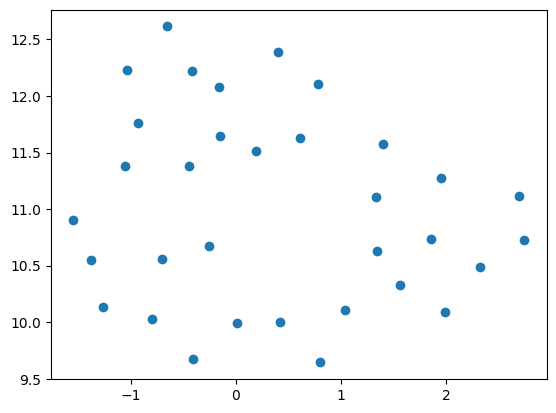

In [142]:
exclude = [
    'MEMS7_OUT_SPORTCOUNT_A01', 'MEMS7_IN_SPORTCOUNT_A01',
    'MEMS7_SPORTCOUNT_A01', 'MEMS7_ALL', 'LA_2023', 'id', 'lad_code', 
    'lad_name', 'total_pop', 'asian', 'black', 'mixed', 'white', 'other'
    'pop_per_km2']
cols = [c for c in env.columns if c not in exclude]
env = env[cols]
env = env.fillna(env.mean())
emb = do_umap(env.values)
plt.scatter(emb[:,0], emb[:,1])

<Axes: >

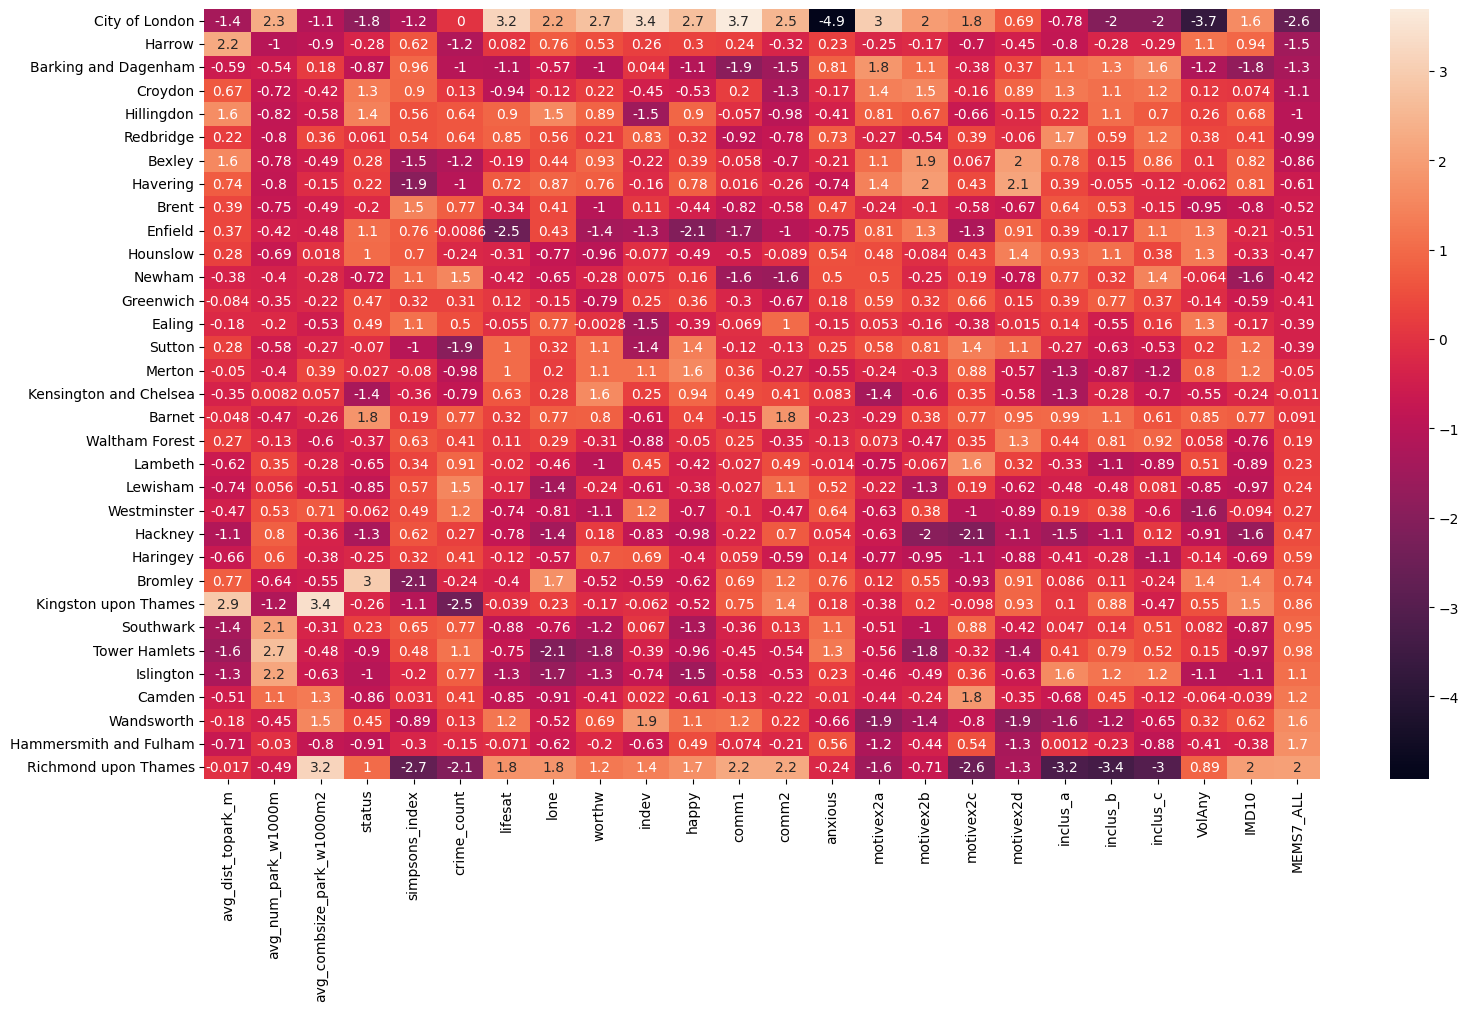

In [159]:
env_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\exploration\data\boroughs\cleaned\borough_profiles.csv'
env = pd.read_csv(env_path)
exclude = [
    'MEMS7_OUT_SPORTCOUNT_A01', 'MEMS7_IN_SPORTCOUNT_A01',
    'MEMS7_SPORTCOUNT_A01', 'LA_2023', 'id', 'lad_code', 
    'lad_name', 'total_pop', 'asian', 'black', 'mixed', 'white', 'other',
    'pop_per_km2']
cols = [c for c in env.columns if c not in exclude]
env = env.sort_values('MEMS7_ALL')
env_c = env[cols]
env_c = env_c.fillna(env_c.mean())
scaler = StandardScaler()
X = env_c.values
X_scaled = scaler.fit_transform(X)
plt.figure(figsize=(18, 10))
sns.heatmap(
    X_scaled,
    annot=True,
    xticklabels = env_c.columns,
    yticklabels = env['lad_name'].values
    
)